Silhouette Score: 0.295
Carte sauvegardée sous clusters_map.html


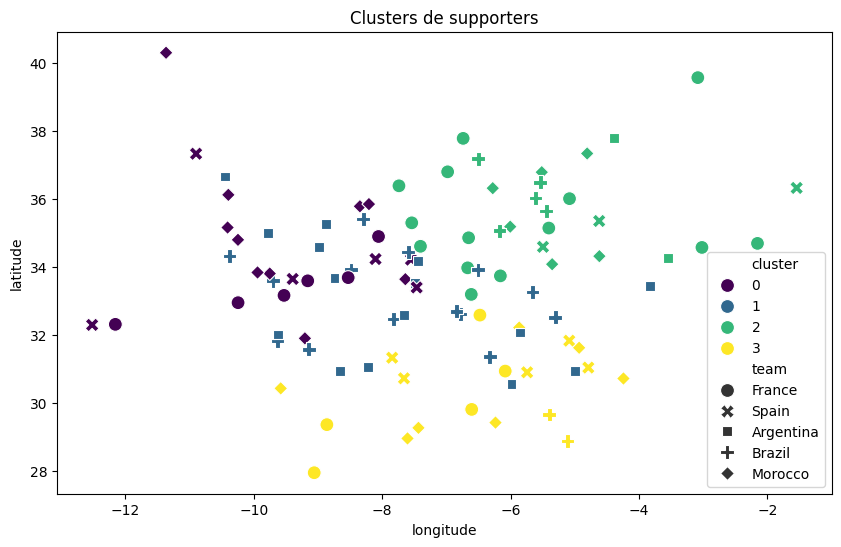

Modèle sauvegardé sous fan_cluster_model.pkl


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import folium
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

class FanClustering:
    def __init__(self, algorithm='kmeans', n_clusters=5, eps=0.5, min_samples=5):
        """
        Initialise le modèle de clustering

        Paramètres:
        - algorithm: 'kmeans' ou 'dbscan'
        - n_clusters: nombre de clusters pour KMeans
        - eps: distance pour DBSCAN
        - min_samples: minimum d'échantillons pour DBSCAN
        """
        self.algorithm = algorithm
        self.n_clusters = n_clusters
        self.eps = eps
        self.min_samples = min_samples
        self.scaler = StandardScaler()
        self.encoder = LabelEncoder()
        self.model = None

    def preprocess_data(self, df):
        """
        Prétraite les données:
        - Encodage de l'équipe
        - Normalisation des features
        """
        # Nettoyage des données manquantes
        df = df.dropna()

        # Encodage de l'équipe
        df["team_encoded"] = self.encoder.fit_transform(df["team"])

        # Sélection des features
        features = df[["latitude", "longitude", "team_encoded"]]

        # Normalisation
        X = self.scaler.fit_transform(features)

        return df, X

    def fit(self, df):
        """
        Entraîne le modèle de clustering
        """
        # Prétraitement
        df, X = self.preprocess_data(df)

        # Choix de l'algorithme
        if self.algorithm == 'kmeans':
            self.model = KMeans(n_clusters=self.n_clusters, random_state=42)
        elif self.algorithm == 'dbscan':
            self.model = DBSCAN(eps=self.eps, min_samples=self.min_samples)
        else:
            raise ValueError("Algorithm not supported. Choose 'kmeans' or 'dbscan'")

        # Entraînement
        df["cluster"] = self.model.fit_predict(X)

        return df

    def evaluate(self, X, labels):
        """
        Évalue la qualité du clustering
        """
        if len(np.unique(labels)) > 1:  # Silhouette nécessite au moins 2 clusters
            score = silhouette_score(X, labels)
            print(f"Silhouette Score: {score:.3f}")
        else:
            print("Pas assez de clusters pour évaluation")

    def visualize_map(self, df, save_path="clusters_map.html"):
        """
        Visualise les clusters sur une carte interactive
        """
        # Création de la carte centrée sur les données
        avg_lat = df['latitude'].mean()
        avg_lon = df['longitude'].mean()
        map = folium.Map(location=[avg_lat, avg_lon], zoom_start=5)

        # Palette de couleurs
        colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred',
                 'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue']

        # Ajout des marqueurs
        for i, row in df.iterrows():
            color = colors[row['cluster'] % len(colors)] if row['cluster'] != -1 else 'gray'

            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=5,
                color=color,
                fill=True,
                fill_color=color,
                popup=f"Team: {row['team']}, Cluster: {row['cluster']}"
            ).add_to(map)

        map.save(save_path)
        print(f"Carte sauvegardée sous {save_path}")

    def visualize_scatter(self, df):
        """
        Visualisation des clusters avec un scatter plot
        """
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=df,
            x="longitude",
            y="latitude",
            hue="cluster",
            palette="viridis",
            style="team",
            s=100
        )
        plt.title("Clusters de supporters")
        plt.show()

    def save_model(self, path="fan_cluster_model.pkl"):
        """
        Sauvegarde le modèle entraîné
        """
        joblib.dump({
            'model': self.model,
            'scaler': self.scaler,
            'encoder': self.encoder,
            'algorithm': self.algorithm
        }, path)
        print(f"Modèle sauvegardé sous {path}")

    @classmethod
    def load_model(cls, path="fan_cluster_model.pkl"):
        """
        Charge un modèle sauvegardé
        """
        data = joblib.load(path)
        instance = cls(algorithm=data['algorithm'])
        instance.model = data['model']
        instance.scaler = data['scaler']
        instance.encoder = data['encoder']
        return instance


# Exemple d'utilisation
if __name__ == "__main__":
    # Création de données exemple
    data = {
        'user_id': range(100),
        'latitude': np.random.normal(33.5731, 2, 100),
        'longitude': np.random.normal(-7.5898, 2, 100),
        'team': np.random.choice(['Morocco', 'Spain', 'France', 'Brazil', 'Argentina'], 100)
    }
    df = pd.DataFrame(data)

    # Initialisation et entraînement du modèle
    fan_cluster = FanClustering(algorithm='kmeans', n_clusters=4)
    df = fan_cluster.fit(df)

    # Évaluation
    _, X = fan_cluster.preprocess_data(df)
    fan_cluster.evaluate(X, df["cluster"])

    # Visualisation
    fan_cluster.visualize_map(df)
    fan_cluster.visualize_scatter(df)

    # Sauvegarde du modèle
    fan_cluster.save_model()

In [2]:
# Pour KMeans (nombre de clusters fixé)
model = FanClustering(algorithm='kmeans', n_clusters=5)

# Pour DBSCAN (clustering basé sur la densité)
model = FanClustering(algorithm='dbscan', eps=0.3, min_samples=10)

In [4]:
import pandas as pd
import numpy as np
import folium
# Supposons que votre classe est dans ce fichier

# Création de données de test
np.random.seed(42)
data = {
    'user_id': range(100),
    'latitude': np.concatenate([
        np.random.normal(33.5731, 0.5, 30),  # Maroc
        np.random.normal(40.4168, 0.5, 25),  # Espagne
        np.random.normal(48.8566, 0.5, 25),  # France
        np.random.normal(35.6762, 0.5, 20),  # Japon
    ]),
    'longitude': np.concatenate([
        np.random.normal(-7.5898, 0.5, 30),  # Maroc
        np.random.normal(-3.7038, 0.5, 25),  # Espagne
        np.random.normal(2.3522, 0.5, 25),   # France
        np.random.normal(139.6503, 0.5, 20), # Japon
    ]),
    'team': ['Morocco']*30 + ['Spain']*25 + ['France']*25 + ['Japan']*20
}

df = pd.DataFrame(data)

# Création du modèle et clustering
model = FanClustering(algorithm='kmeans', n_clusters=4)
df = model.fit(df)

# Génération de la carte
model.visualize_map(df, "ma_carte.html")

Carte sauvegardée sous ma_carte.html
